In [13]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')
os.environ['LANGSMITH_TRACING']="true"


In [15]:
from langchain_groq import ChatGroq

# model=ChatGroq(model='openai/gpt-oss-20b')
llm=ChatGroq(    model="openai/gpt-oss-20b"
)

In [16]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016149045150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001614A705A10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [17]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [18]:
## Graph With tool Call
from langchain_core.tools import tool

@tool
def add(a:float,b:float):
    """Add two number"""
    return a+b
tools=[add]
tool_node=ToolNode([add])

llm_with_tool=llm.bind_tools([add])

def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}


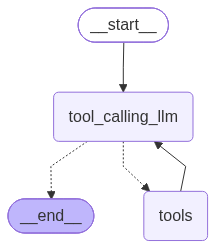

In [20]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
response=graph.invoke({"messages":"What is machine learning"})

In [22]:
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='bb699d72-53b2-4341-bfc9-d6459e4a931a'),
  AIMessage(content='**Machine Learning (ML)** is a subfield of artificial intelligence that focuses on building systems that can *learn* from data, improve over time, and make predictions or decisions without being explicitly programmed for each task.\n\n---\n\n## 1. Core Idea\n\n- **Data‑driven learning**: Instead of coding every rule, you give the system a large set of examples (data) and let it discover patterns.\n- **Model training**: Algorithms create a mathematical model that maps inputs to outputs.\n- **Prediction/Decision**: Once trained, the model can apply what it learned to new, unseen data.\n\n---\n\n## 2. Key Concepts\n\n| Concept | What it means | Example |\n|---------|---------------|---------|\n| **Features** | Measurable properties of the data (e.g., pixel values, word counts). | In an email spam filter, features could 

In [23]:
response=graph.invoke({"messages":"what is 5 plus 20"})

In [24]:
response

{'messages': [HumanMessage(content='what is 5 plus 20', additional_kwargs={}, response_metadata={}, id='8d228300-1410-4fb5-a7df-8b54261b4e23'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is 5 plus 20". We need to compute 5 + 20 = 25. According to instructions, we must use the function "functions.add" to compute. So we should call the function with a=5, b=20.', 'tool_calls': [{'id': 'fc_e35aeaa3-af0f-4edb-bba4-fe98f7599696', 'function': {'arguments': '{"a":5,"b":20}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 127, 'total_tokens': 211, 'completion_time': 0.136403487, 'completion_tokens_details': {'reasoning_tokens': 58}, 'prompt_time': 0.010183823, 'prompt_tokens_details': None, 'queue_time': 0.046203936, 'total_time': 0.14658731}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprob